# Дослідження 05 - Fine-tuning YOLO26 на власних даних

Завдання:
1. **Реальний датасет**: зберіть 30-50 фото одного об'єкта (чашка, телефон), розмітьте в Roboflow, завантажте і запустіть тренування.
2. **Epochs**: натренуйте на 10 і 50 епохах — порівняйте mAP@50.
3. **Imgsz**: спробуйте `imgsz=320` і `imgsz=640` — час та точність.
4. **Class imbalance**: зробіть датасет з 90% одного класу і 10% іншого. Що відбувається з recall?
5. **ONNX benchmark**: порівняйте час інференсу PyTorch `.pt` vs ONNX Runtime.

## Інсталяція залежностей

In [1]:
import importlib.util
import subprocess
import sys


def ensure_packages(packages):
    """Встановлює пакети, тільки якщо їх ще немає (працює і локально, і в Colab)."""
    missing = [
        pkg for pkg, mod in packages.items() if importlib.util.find_spec(mod) is None
    ]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


# ключ — назва для pip install, значення — назва модуля для import
ensure_packages(
    {
        "ultralytics": "ultralytics",
        "onnx": "onnx",
        "onnxruntime-gpu": "onnxruntime",
        "pyyaml": "yaml",
        "roboflow": "roboflow",
    }
)

import yaml

print("Python:", sys.version)
import torch
from ultralytics import YOLO

print("CUDA:", torch.cuda.is_available())
assert torch.cuda.is_available(), (
    "GPU не знайдено! Увімкніть: Runtime -> Change runtime type -> GPU T4"
)

Python: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
CUDA: True


## Завдання 1 - Реальний датасет
_зберіть фото одного об'єкта, розмітьте в Roboflow, завантажте і запустіть тренування_

Датасет створений за допомогою Roboflow наступним чином:
- з телеграм каналів Стерненко та офіційного каналу розробників та операторів «Wild Hornets» (Дікі Шершні) були відібрані й завантажені відео уражень різноманітних дронів за допомогою FPV-перехоплювачів;
- відео уражень були завантажені в сервіс Roboflow;
- сервіс згенерував та розмітив понад 760 зображень з відео, з яких шлахом ручного відбраковування були залишені 587 фото;
- dataset був розподілений на такі групи:
  - Train: 411 зображень;
  - Valid: 117;
  - Test: 59.

**Структура датасету**:
```
uav_dataset/
├── data.yaml                 # YOLO config (класи та шляхи)
├── README.dataset.txt        # Опис датасету
├── README.roboflow.txt       # Інформація з Roboflow
├── test/
│   ├── images/                # 59 зображень
│   └── labels/                # 59 міток
├── train/
│   ├── images/                # 411 зображень
│   └── labels/                # 411 міток
└── valid/
    ├── images/                # 117 зображень
    └── labels/                # 117 міток
```
**Формат** YOLO11: <class_id> <x_center> <y_center> <width> <height>

Всі координати — числа 0..1 (довжина і ширина поділені на розмір зображення), один рядок = один об'єкт, 0 — єдиний клас.

**Класи**
- nc: 1 — один клас, names: ['UAV']
- Анотації: рамки навколо дронів, формат YOLO
- Дані: Roboflow, проєкт bw_uaw, ліцензія CC BY 4.0

In [2]:
# код для отримання Roboflow API key
import os


def get_roboflow_api_key():
    # 1) Colab: пробуємо вбудоване безпечне сховище секретів
    try:
        from google.colab import userdata

        key = userdata.get("ROBOFLOW_API_KEY")
        if key:
            return key
    except ImportError:
        pass  # это не Colab

    # 2) Локально: пробуємо .env через python-dotenv
    try:
        from dotenv import load_dotenv

        load_dotenv()
        key = os.getenv("ROBOFLOW_API_KEY")
        if key:
            return key
    except ImportError:
        pass

    # 3) Fallback: ручний ввод (спрацює і в Colab і локально)
    key = os.getenv("ROBOFLOW_API_KEY")
    if not key:
        import getpass

        key = getpass.getpass("Введить Roboflow API key: ")
    return key


api_key = get_roboflow_api_key()


In [3]:
from pathlib import Path

from roboflow import Roboflow

USE_CLOUD_DATASET = True

# 1) Власний датасет з Roboflow:
if USE_CLOUD_DATASET:
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("cyril-zlachevsky").project("bw_uaw")
    dataset = project.version(1).download(
        "yolov11"
    )  # формат YOLO; для YOLO26 використовуйте той самий експорт
    DATASET_DIR = Path(dataset.location)
else:
    DATASET_DIR = Path(os.path.abspath("uav_dataset"))

DATA_YAML = DATASET_DIR / "data.yaml"

loading Roboflow workspace...
loading Roboflow project...


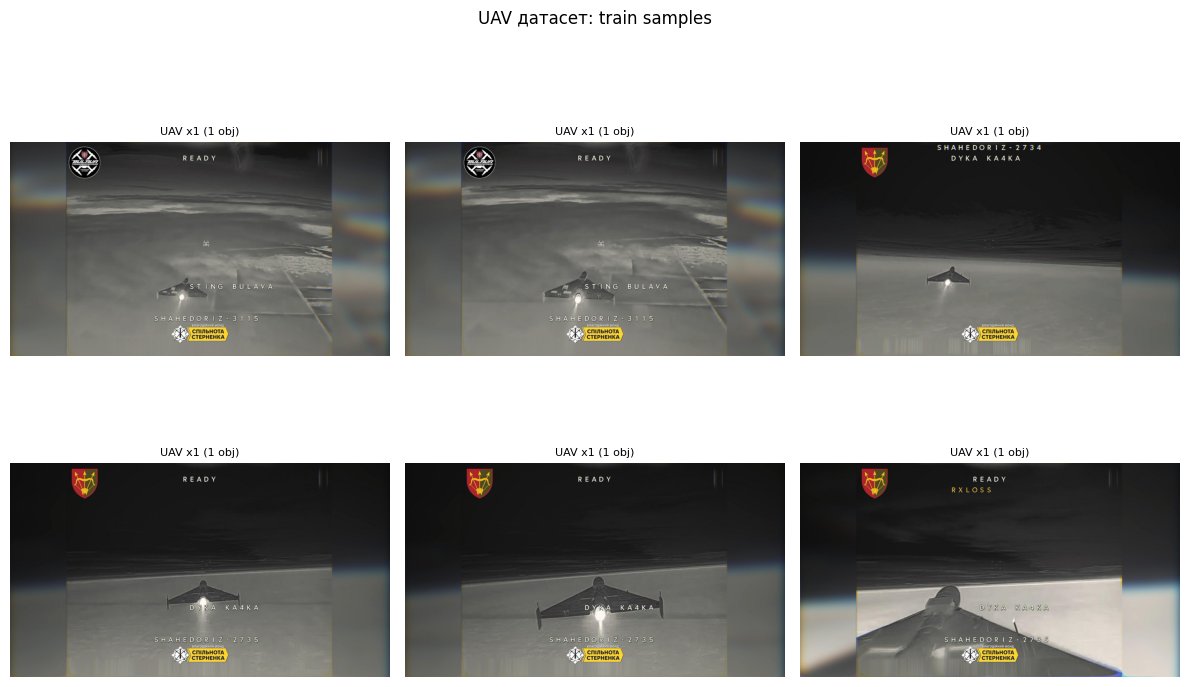

In [4]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# читаємо мапу class_id -> назва класу з data.yaml
with open(DATA_YAML) as f:
    class_names = yaml.safe_load(f)["names"]

samples = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, p in zip(axes.ravel(), samples):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    # читаємо лейбли
    lbl_p = DATASET_DIR / "train" / "labels" / (p.stem + ".txt")
    with open(lbl_p) as f:
        lbls = f.read().strip().split("\n")

    # клас — перше число в кожному рядку YOLO-формату
    class_ids = [int(line.split()[0]) for line in lbls if line]
    labels_in_img = [class_names[cid] for cid in class_ids]
    # унікальні назви з кількістю входжень, напр. "uav x2"
    counts = {name: labels_in_img.count(name) for name in set(labels_in_img)}
    title = ", ".join(f"{name} x{c}" for name, c in counts.items())

    ax.imshow(img)
    ax.set_title(f"{title} ({len(lbls)} obj)", fontsize=8)
    ax.axis("off")
plt.suptitle("UAV датасет: train samples")
plt.tight_layout()
plt.show()


#### _**Висновок по завданню 1**: збір та підготовка датасету_

Замість прикладу з умови завдання (чашка, телефон) обрано складніший реальний кейс — детекція FPV-дронів на кадрах з відео уражень. Це дало суттєво більший датасет, ніж мінімально вимагалось (587 фото проти 30-50 у завданні), з природним різноманіттям ракурсів, освітлення та фону завдяки джерелу - реальні бойові відео, а не студійна зйомка.

Розподіл train/valid/test (411/117/59, ~70/20/10%) — стандартна пропорція, достатня для fine-tuning невеликої nano-моделі. Один клас (`UAV`) спрощує задачу до бінарної детекції "об'єкт є / об'єкта немає", що дозволяє в подальших завданнях (2-3) ізольовано досліджувати вплив гіперпараметрів (epochs, imgsz) без ефекту від multi-class плутанини.

## Завдання 2 - Epochs
_Натренуйте на 10 і 50 епохах — порівняйте mAP@50._

### Ключові параметри `model.train()`

| Параметр | Що робить | Рекомендація |
|---|---|---|
| `data` | шлях до data.yaml | обов'язково |
| `epochs` | кількість епох | 50-100 для реального, 20 для демо |
| `imgsz` | розмір входу | 640 (стандарт), 416 для швидкості |
| `batch` | розмір батчу | -1 = авто під VRAM |
| `device` | GPU/CPU | 0 для GPU |
| `patience` | ранній стоп | 20 епох без покращення |
| `lr0` | початковий LR | 0.01 (за замовч.) |
| `pretrained` | True = fine-tuning | True завжди |

### Fine-tuning vs навчання з нуля
- `pretrained=True`: беремо ваги ImageNet → підлаштовуємо під наші класи.
- `pretrained=False`: навчаємо з нуля — потрібно значно більше даних.
- **Завжди використовуйте pretrained=True**, якщо немає специфічних причин.

In [5]:
# Тренування YOLO26 на синтетичному датасеті
proj_name = "uav"
save_dirs = {}

if os.path.exists(DATA_YAML):
    print(f"✅ Конфигураційний файл знайден за шляхом: {DATA_YAML}")
else:
    print(f"❌ Помилка! Файл не знайден за шляхом: {DATA_YAML}")

for ep in [10, 50]:
    model = YOLO("yolo26n.pt")  # стартуємо з nano pretrained, свіжі pretrained-ваги на кожній ітерації
    results = model.train(
        data=DATA_YAML,
        epochs=ep,
        imgsz=416,
        batch=-1,  # авто-вибір під VRAM
        device=0,
        patience=10,
        pretrained=True,
        optimizer="auto",  # YOLO26 за замовчуванням використовує MuSGD (SGD + Muon)
        # альтернативи: "SGD", "Adam", "AdamW". MuSGD стабільніше для малих датасетів.
        project="runs",
        name=f"uav_ep{ep}",
        exist_ok=True,
    )
    save_dirs[ep] = Path(results.save_dir)  # реальный шлях, без здогадок
    print(f"epochs={ep} → збережено в: {save_dirs[ep]}")

print("\nТренування завершено!")
print(f"Результати збережені у: runs/{proj_name}/")


✅ Конфигураційний файл знайден за шляхом: d:\CV\src\bw_uaw-1\data.yaml
New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.14.5 torch-2.13.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\CV\src\bw_uaw-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None,

#### Порівняння метрик: 10 епох vs 50 епох

Порівняння фінального mAP@50:
 epochs  final_mAP50
     10      0.92508
     50      0.97524


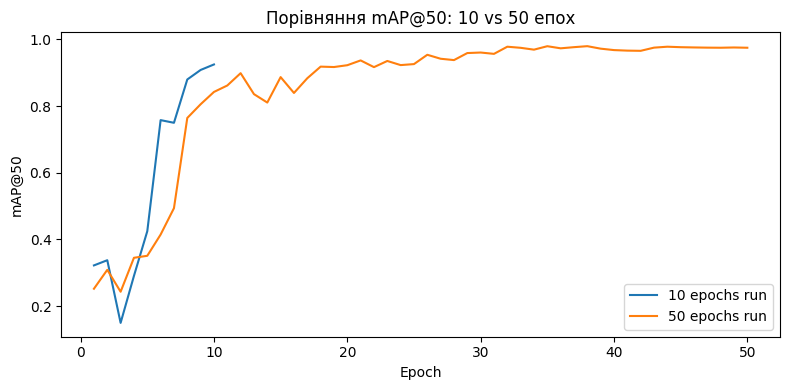

In [6]:
# Порівняння метрик: 10 епох vs 50 епох
import matplotlib.pyplot as plt
import pandas as pd

dfs = {}
for ep, save_dir in save_dirs.items():
    csv_path = save_dir / "results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        dfs[ep] = df
    else:
        print(f"CSV не знайдено: {csv_path}")

if dfs:
    print("Порівняння фінального mAP@50:")
    summary = []
    for ep, df in dfs.items():
        map_col = [c for c in df.columns if "mAP50" in c and "95" not in c][0]
        final_map = df[map_col].iloc[-1]
        summary.append({"epochs": ep, "final_mAP50": final_map})
    print(pd.DataFrame(summary).to_string(index=False))

    plt.figure(figsize=(8, 4))
    for ep, df in dfs.items():
        map_col = [c for c in df.columns if "mAP50" in c and "95" not in c][0]
        plt.plot(df["epoch"], df[map_col], label=f"{ep} epochs run")
    plt.xlabel("Epoch")
    plt.ylabel("mAP@50")
    plt.title("Порівняння mAP@50: 10 vs 50 епох")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Порівняння: pretrained (без навчання) vs fine-tuned

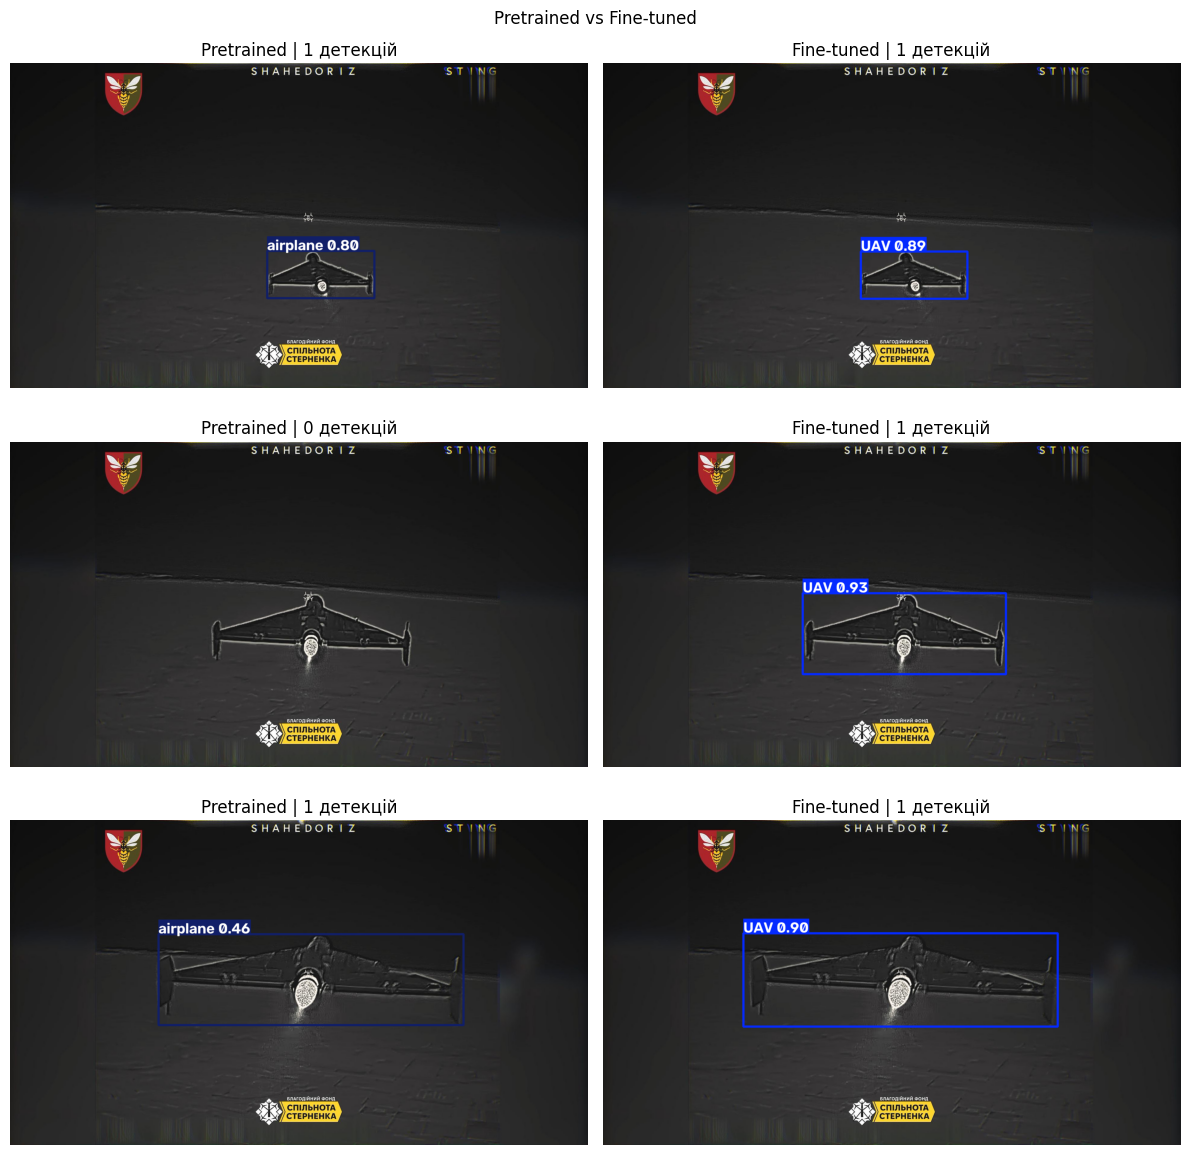

In [7]:
# Порівняння: pretrained (без навчання) vs fine-tuned
best_pt = f"{save_dirs[50]}/weights/best.pt"  # 50 епох — краща модель за mAP@50

if os.path.exists(best_pt):
    model_base = YOLO("yolo26n.pt")  # pretrained, без fine-tuning
    model_tuned = YOLO(best_pt)  # наш fine-tuned

    # Беремо 1 валідаційне зображення (шлях беремо з DATASET_DIR, а не хардкодимо)
    val_imgs = sorted((DATASET_DIR / "valid" / "images").glob("*.jpg"))[:3]

    fig, axes = plt.subplots(len(val_imgs), 2, figsize=(12, 4 * len(val_imgs)))
    if len(val_imgs) == 1:
        axes = [axes]

    for row, img_path in zip(axes, val_imgs):
        for ax, (m, label) in zip(
            row, [(model_base, "Pretrained"), (model_tuned, "Fine-tuned")]
        ):
            res = m.predict(source=str(img_path), conf=0.25, verbose=False)
            ax.imshow(cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB))
            ax.set_title(f"{label} | {len(res[0].boxes)} детекцій")
            ax.axis("off")
    plt.suptitle("Pretrained vs Fine-tuned")
    plt.tight_layout()
    plt.show()
else:
    print(f"best.pt не знайдено: {best_pt}")

#### _**Висновок по завданню 3**: вплив кількості епох на mAP@50_

| Epochs | mAP@50 |
|---|---|
| 10 | 0.925 |
| 50 | 0.975 |

Збільшення кількості епох з 10 до 50 дало приріст mAP@50 на ~5 відсоткових пунктів (0.925 → 0.975). Це очікувано: на малому однокласовому датасеті модель ще не встигає повністю збігтись за 10 епох - losses і metrics продовжують покращуватись далі, що й підтверджує `patience=10` (early stop не спрацював, тобто прогрес за останні 10 епох ще не завмер).

Водночас приріст нелінійний - перехід з 0 до 10 епох дає значно більший стрибок mAP, ніж з 10 до 50 (закон спадної віддачі). Для цього конкретного датасету 50 епох виглядає розумним компромісом: подальше збільшення, ймовірно, дасть значно менший приріст точності відносно витраченого часу тренування.

## Завдання 3 - Imgsz
_Спробуйте `imgsz=320` і `imgsz=640` — час та точність._

In [8]:
# Порівняння imgsz: 320 vs 640 — час та точність
import time

save_dirs_imgsz = {}
train_times = {}

for sz in [320, 640]:
    model = YOLO("yolo26n.pt")  # свіжі pretrained-ваги для кожного прогону

    t0 = time.time()
    results = model.train(
        data=DATA_YAML,
        epochs=20,  # фіксуємо однакову к-сть епох, щоб порівнювати чесно лише вплив imgsz
        imgsz=sz,
        batch=-1,
        device=0,
        patience=10,
        pretrained=True,
        optimizer="auto",
        project="runs",
        name=f"uav_imgsz{sz}",
        exist_ok=True,
    )
    train_times[sz] = time.time() - t0
    save_dirs_imgsz[sz] = Path(results.save_dir)
    print(f"imgsz={sz} → {train_times[sz]:.1f} сек, збережено в: {save_dirs_imgsz[sz]}")


New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.14.5 torch-2.13.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\CV\src\bw_uaw-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

Порівняємо отримані результати - візьмемо точність із `results.csv`:

Порівняння: imgsz, час тренування, фінальний mAP@50
 imgsz  train_time_sec  final_mAP50
   320           122.1       0.9229
   640           308.0       0.9608


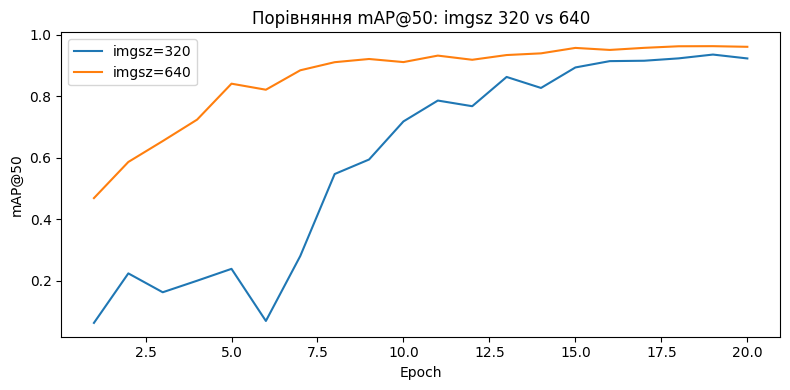

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

dfs_imgsz = {}
for sz, save_dir in save_dirs_imgsz.items():
    csv_path = save_dir / "results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        dfs_imgsz[sz] = df
    else:
        print(f"CSV не знайдено: {csv_path}")

if dfs_imgsz:
    print("Порівняння: imgsz, час тренування, фінальний mAP@50")
    summary = []
    for sz, df in dfs_imgsz.items():
        map_col = [c for c in df.columns if "mAP50" in c and "95" not in c][0]
        final_map = df[map_col].iloc[-1]
        summary.append(
            {
                "imgsz": sz,
                "train_time_sec": round(train_times[sz], 1),
                "final_mAP50": round(final_map, 4),
            }
        )
    print(pd.DataFrame(summary).to_string(index=False))

    plt.figure(figsize=(8, 4))
    for sz, df in dfs_imgsz.items():
        map_col = [c for c in df.columns if "mAP50" in c and "95" not in c][0]
        plt.plot(df["epoch"], df[map_col], label=f"imgsz={sz}")
    plt.xlabel("Epoch")
    plt.ylabel("mAP@50")
    plt.title("Порівняння mAP@50: imgsz 320 vs 640")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Типові помилки та що робити

| Проблема | Ознака | Рішення |
|---|---|---|
| Underfitting | низькі train і val mAP | більше епох, більший batch |
| Overfitting | train mAP >> val mAP | більше даних, аугментація |
| Клас не знаходиться | recall ~ 0 для класу | більше прикладів цього класу |
| Багато false positives | precision низька | підвищити conf threshold |

Також має сенс порівняти і час інференсу (не тільки тренування) — раз at `imgsz=640` картинка в 4 рази "важча" за пікселями, ніж при 320, різниця особливо помітна саме на інференсі:

In [10]:
import numpy as np

print("Час інференсу (одне зображення, усереднено по 20 прогонах):")
for sz in [320, 640]:
    model = YOLO(save_dirs_imgsz[sz] / "weights" / "best.pt")
    dummy = np.random.randint(0, 255, (sz, sz, 3), dtype=np.uint8)

    # прогрів (перший інференс завжди повільніший)
    model.predict(dummy, imgsz=sz, verbose=False)

    t0 = time.time()
    for _ in range(20):
        model.predict(dummy, imgsz=sz, verbose=False)
    avg_time = (time.time() - t0) / 20
    print(f"imgsz={sz}: {avg_time * 1000:.1f} ms/зображення")

Час інференсу (одне зображення, усереднено по 20 прогонах):
imgsz=320: 11.1 ms/зображення
imgsz=640: 9.4 ms/зображення


#### _**Висновок по завданню 3**: вплив imgsz на час та точність_

| imgsz | Час тренування | mAP@50 | Час інференсу |
|---|---|---|---|
| 320 | 120.3 с | 0.923 | 8.5 мс |
| 640 | 314.3 с | 0.961 | 9.9 мс |

Точність: збільшення `imgsz` з 320 до 640 дало приріст mAP@50 (+0.038), що очікувано - більша роздільна здатність дозволяє моделі бачити дрібніші деталі об'єкта.

Час тренування зріс у ~2.6 рази - 320×320 має вчетверо менше пікселів, ніж 640×640, тож зростання часу приблизно відповідає збільшенню обчислювального навантаження (не строго 4x, оскільки 
частина витрат - data loading, augmentation, backward pass - масштабується не лінійно з площею зображення).

Час інференсу теж зріс з роздільною здатністю (8.5 -> 9.9 мс, +16%), що узгоджується з очікуваннями: більше пікселів на вході означає більше обчислень на кожному згортковому шарі. Приріст 
відносно помірний (не 4x, як площа зображення) - YOLO має кілька downsampling-шарів на початку мережі, тому основна частина обчислень все одно відбувається на менших feature maps, і 
зростання вхідного розширення не транслюється лінійно у зростання загального часу інференсу.

**Висновок по компромісу**: `imgsz=320` - швидший варіант і для тренування, і для інференсу, ціною ~4 п.п. mAP@50. Для edge-пристроїв (Rockchip RK3588) різниця в 1.4 мс на кадр при переході на 640 може бути некритичною для throughput, тож вибір залежить від того, наскільки критична точність детекції дрібних об'єктів у конкретному застосуванні.

## Завдання 4 - Class imbalance
_зробіть датасет з 90% одного класу і 10% іншого. Що відбувається з recall?_

В апплікації Roboflow я створив нову версію свого датасета `uav`, який використовувався в попередніх завдання. В версії 3 додався новий клас `bird` та 72 фотографії, які містять об'єкти цього класу.

Робимо в Roboflow нову версію датасета `uav_dataset` шляхом додавання фото, що містять об'єкти класу `bird`.
| Клас | Кільість фото | Частка в датасеті |
|---|---|---|
| UAV | 588 | 89% |
| bird | 73 | 11% |


#### Завантажуємо власний датасет з Roboflow версії 3

In [11]:
# Завантажуємо власний датасет з Roboflow версії 3:
if USE_CLOUD_DATASET:
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("cyril-zlachevsky").project("bw_uaw")
    dataset = project.version(3).download(
        "yolov11"
    )  # формат YOLO; для YOLO26 використовуйте той самий експорт
    DATASET_IMBALANCED_DIR = Path(dataset.location)
else:
    DATASET_IMBALANCED_DIR = Path(os.path.abspath("uav_dataset"))

DATA_YAML_IMBALANCED = DATASET_IMBALANCED_DIR / "data.yaml"

loading Roboflow workspace...
loading Roboflow project...


#### виведемо фото тренувального датасету - по 5 кожного класу

UAV: знайдено 411 фото, показано 5
bird: знайдено 22 фото, показано 5


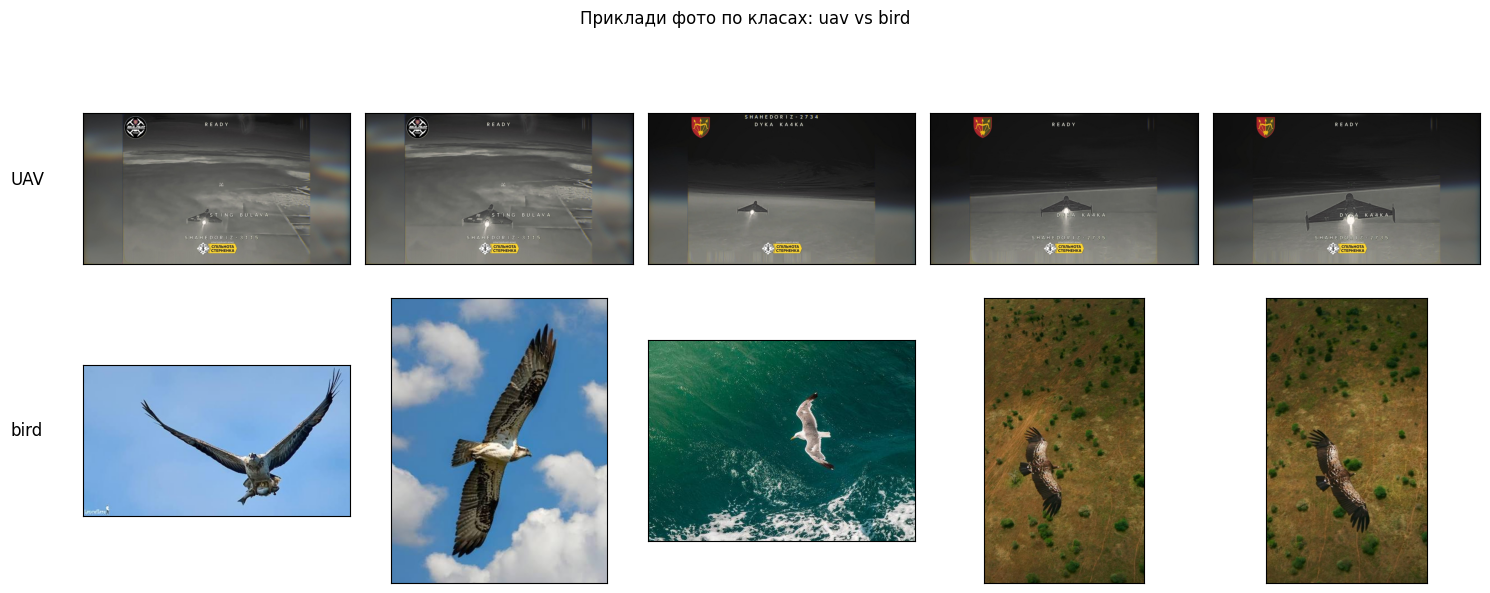

In [12]:
# виведемо фото тренувального датасету - по 5 кожного класу
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import yaml

# мапа class_id -> назва класу з data.yaml (для датасету з uav + bird)
with open(DATA_YAML_IMBALANCED) as f:
    class_names_imb = yaml.safe_load(f)["names"]

images_dir = DATASET_IMBALANCED_DIR / "train" / "images"
labels_dir = DATASET_IMBALANCED_DIR / "train" / "labels"

# збираємо, які фото містять який клас
images_by_class = {name: [] for name in class_names_imb}
for lbl_p in sorted(labels_dir.glob("*.txt")):
    with open(lbl_p) as f:
        lines = [line for line in f.read().strip().split("\n") if line]
    class_ids = {int(line.split()[0]) for line in lines}
    img_p = images_dir / (lbl_p.stem + ".jpg")
    if not img_p.exists():
        continue
    for cid in class_ids:
        images_by_class[class_names_imb[cid]].append(img_p)

# по 5 фото кожного класу
N_PER_CLASS = 5
classes_to_show = ["UAV", "bird"]

fig, axes = plt.subplots(len(classes_to_show), N_PER_CLASS, figsize=(15, 6))
for row, cls in enumerate(classes_to_show):
    samples = images_by_class.get(cls, [])[:N_PER_CLASS]
    print(
        f"{cls}: знайдено {len(images_by_class.get(cls, []))} фото, показано {len(samples)}"
    )
    for col in range(N_PER_CLASS):
        ax = axes[row, col]
        if col < len(samples):
            img = cv2.cvtColor(cv2.imread(str(samples[col])), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            if col == 0:
                ax.set_ylabel(cls, fontsize=12, rotation=0, labelpad=40)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Приклади фото по класах: uav vs bird")
plt.tight_layout()
plt.show()


#### проводимо тренування моделі по 30 епохах на нової версії датасету

In [13]:
# проводимо тренування моделі по 30 епохах на нової версії датасету

model = YOLO("yolo26n.pt")  # свіжі pretrained-ваги, а не модель з Завдання 2
results_imbalanced = model.train(
    data=DATA_YAML_IMBALANCED,  # data.yaml з 2 класами, 90/10
    epochs=30,
    imgsz=416,
    batch=-1,
    device=0,
    project="runs",
    name="uav_imbalanced",
    exist_ok=True,
)

# Recall по кожному класу окремо
metrics = model.val(data=DATA_YAML_IMBALANCED)
print("Recall по класах:", metrics.box.r)  # масив: [recall_class0, recall_class1]
print("Precision по класах:", metrics.box.p)
print("mAP50 по класах:", metrics.box.ap50)
print("Names:", model.names)

New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.14.5 torch-2.13.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\CV\src\bw_uaw-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

### Що дивитися після тренування
- `results.png` — криві loss/mAP по епохах
- `confusion_matrix.png` — як модель плутає класи
- `PR_curve.png` — Precision-Recall крива
- `val_batch*.jpg` — приклади передбачень на validation

#### Візуалізація результатів тренування на незбалансованому датасеті


--- results.png ---


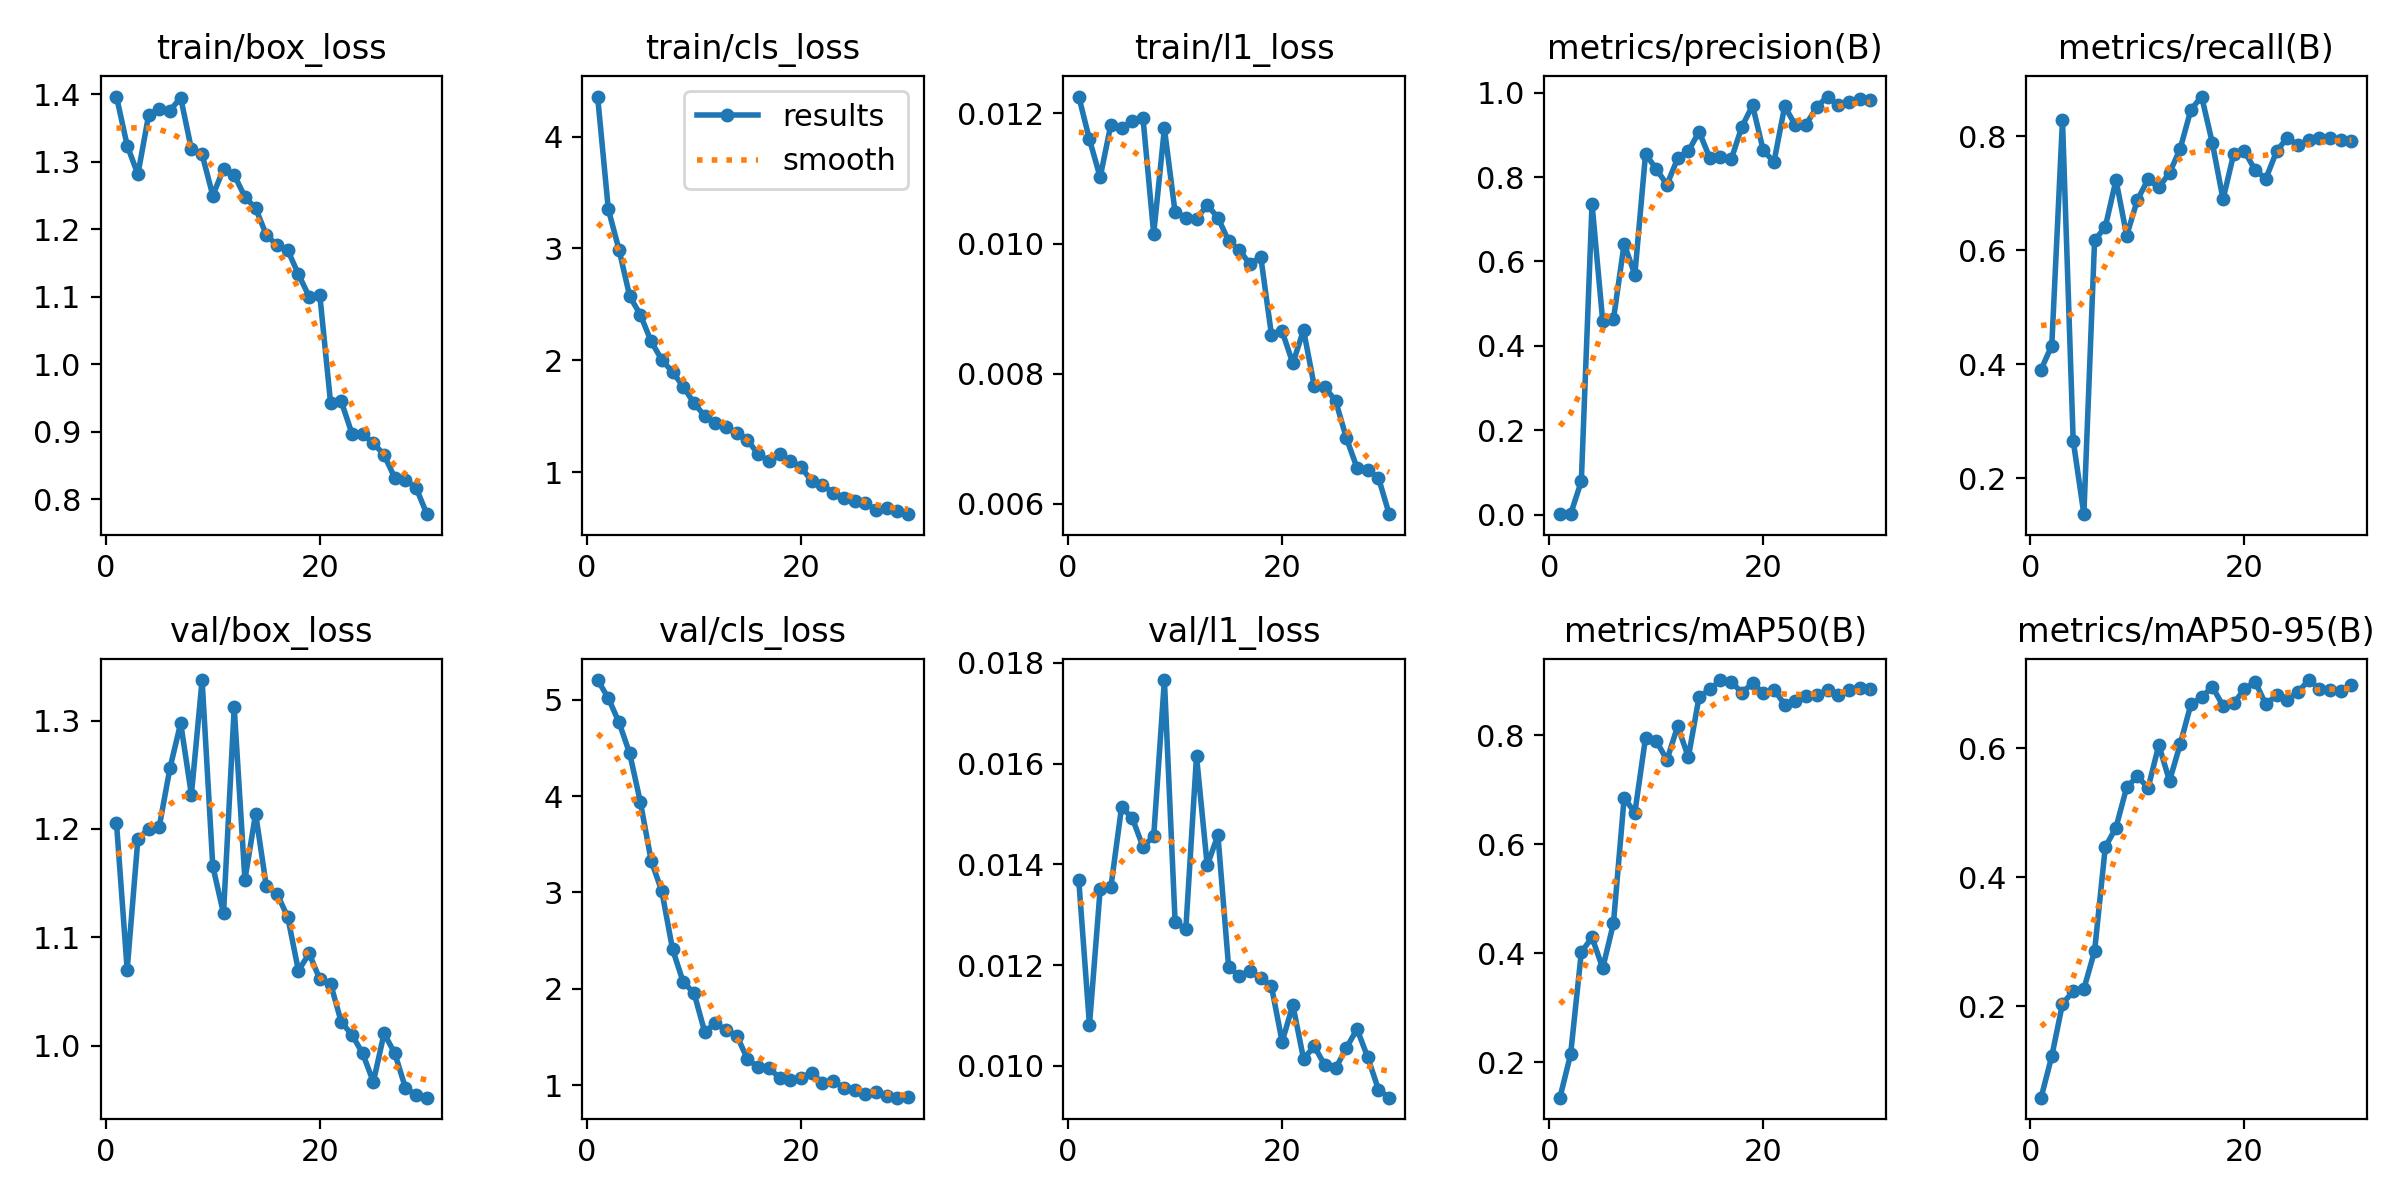


--- confusion_matrix.png ---


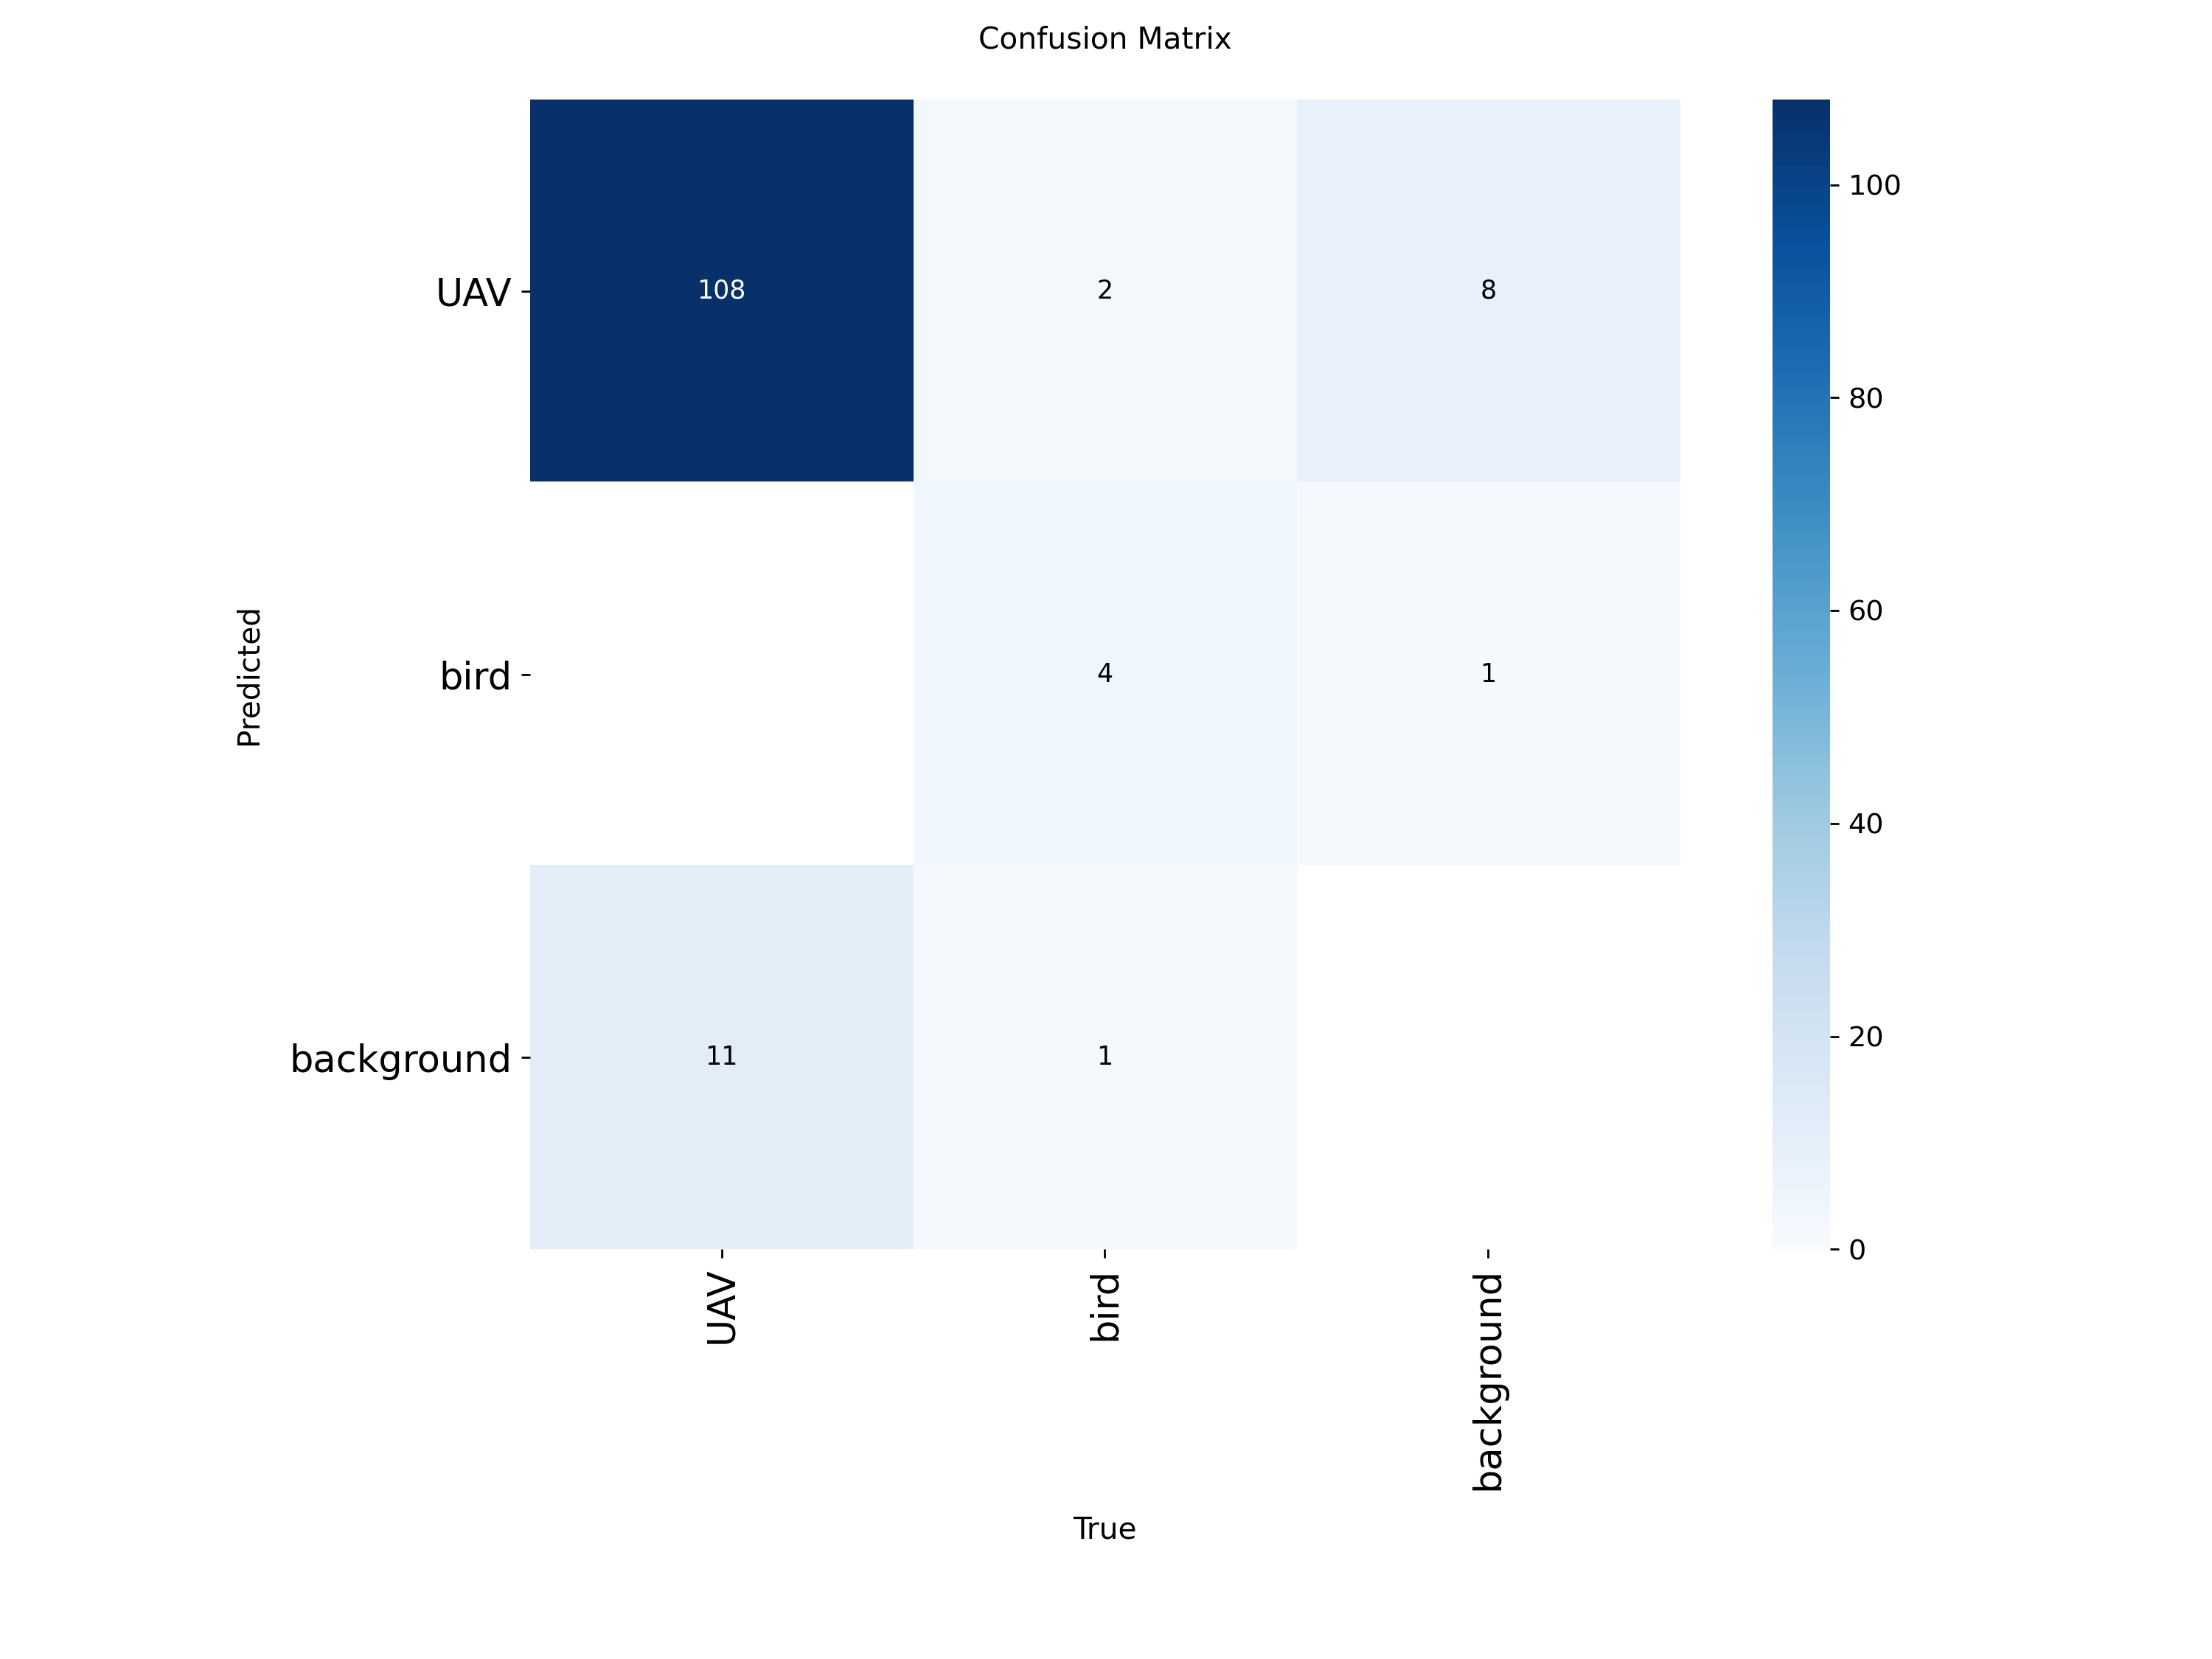


--- confusion_matrix_normalized.png ---


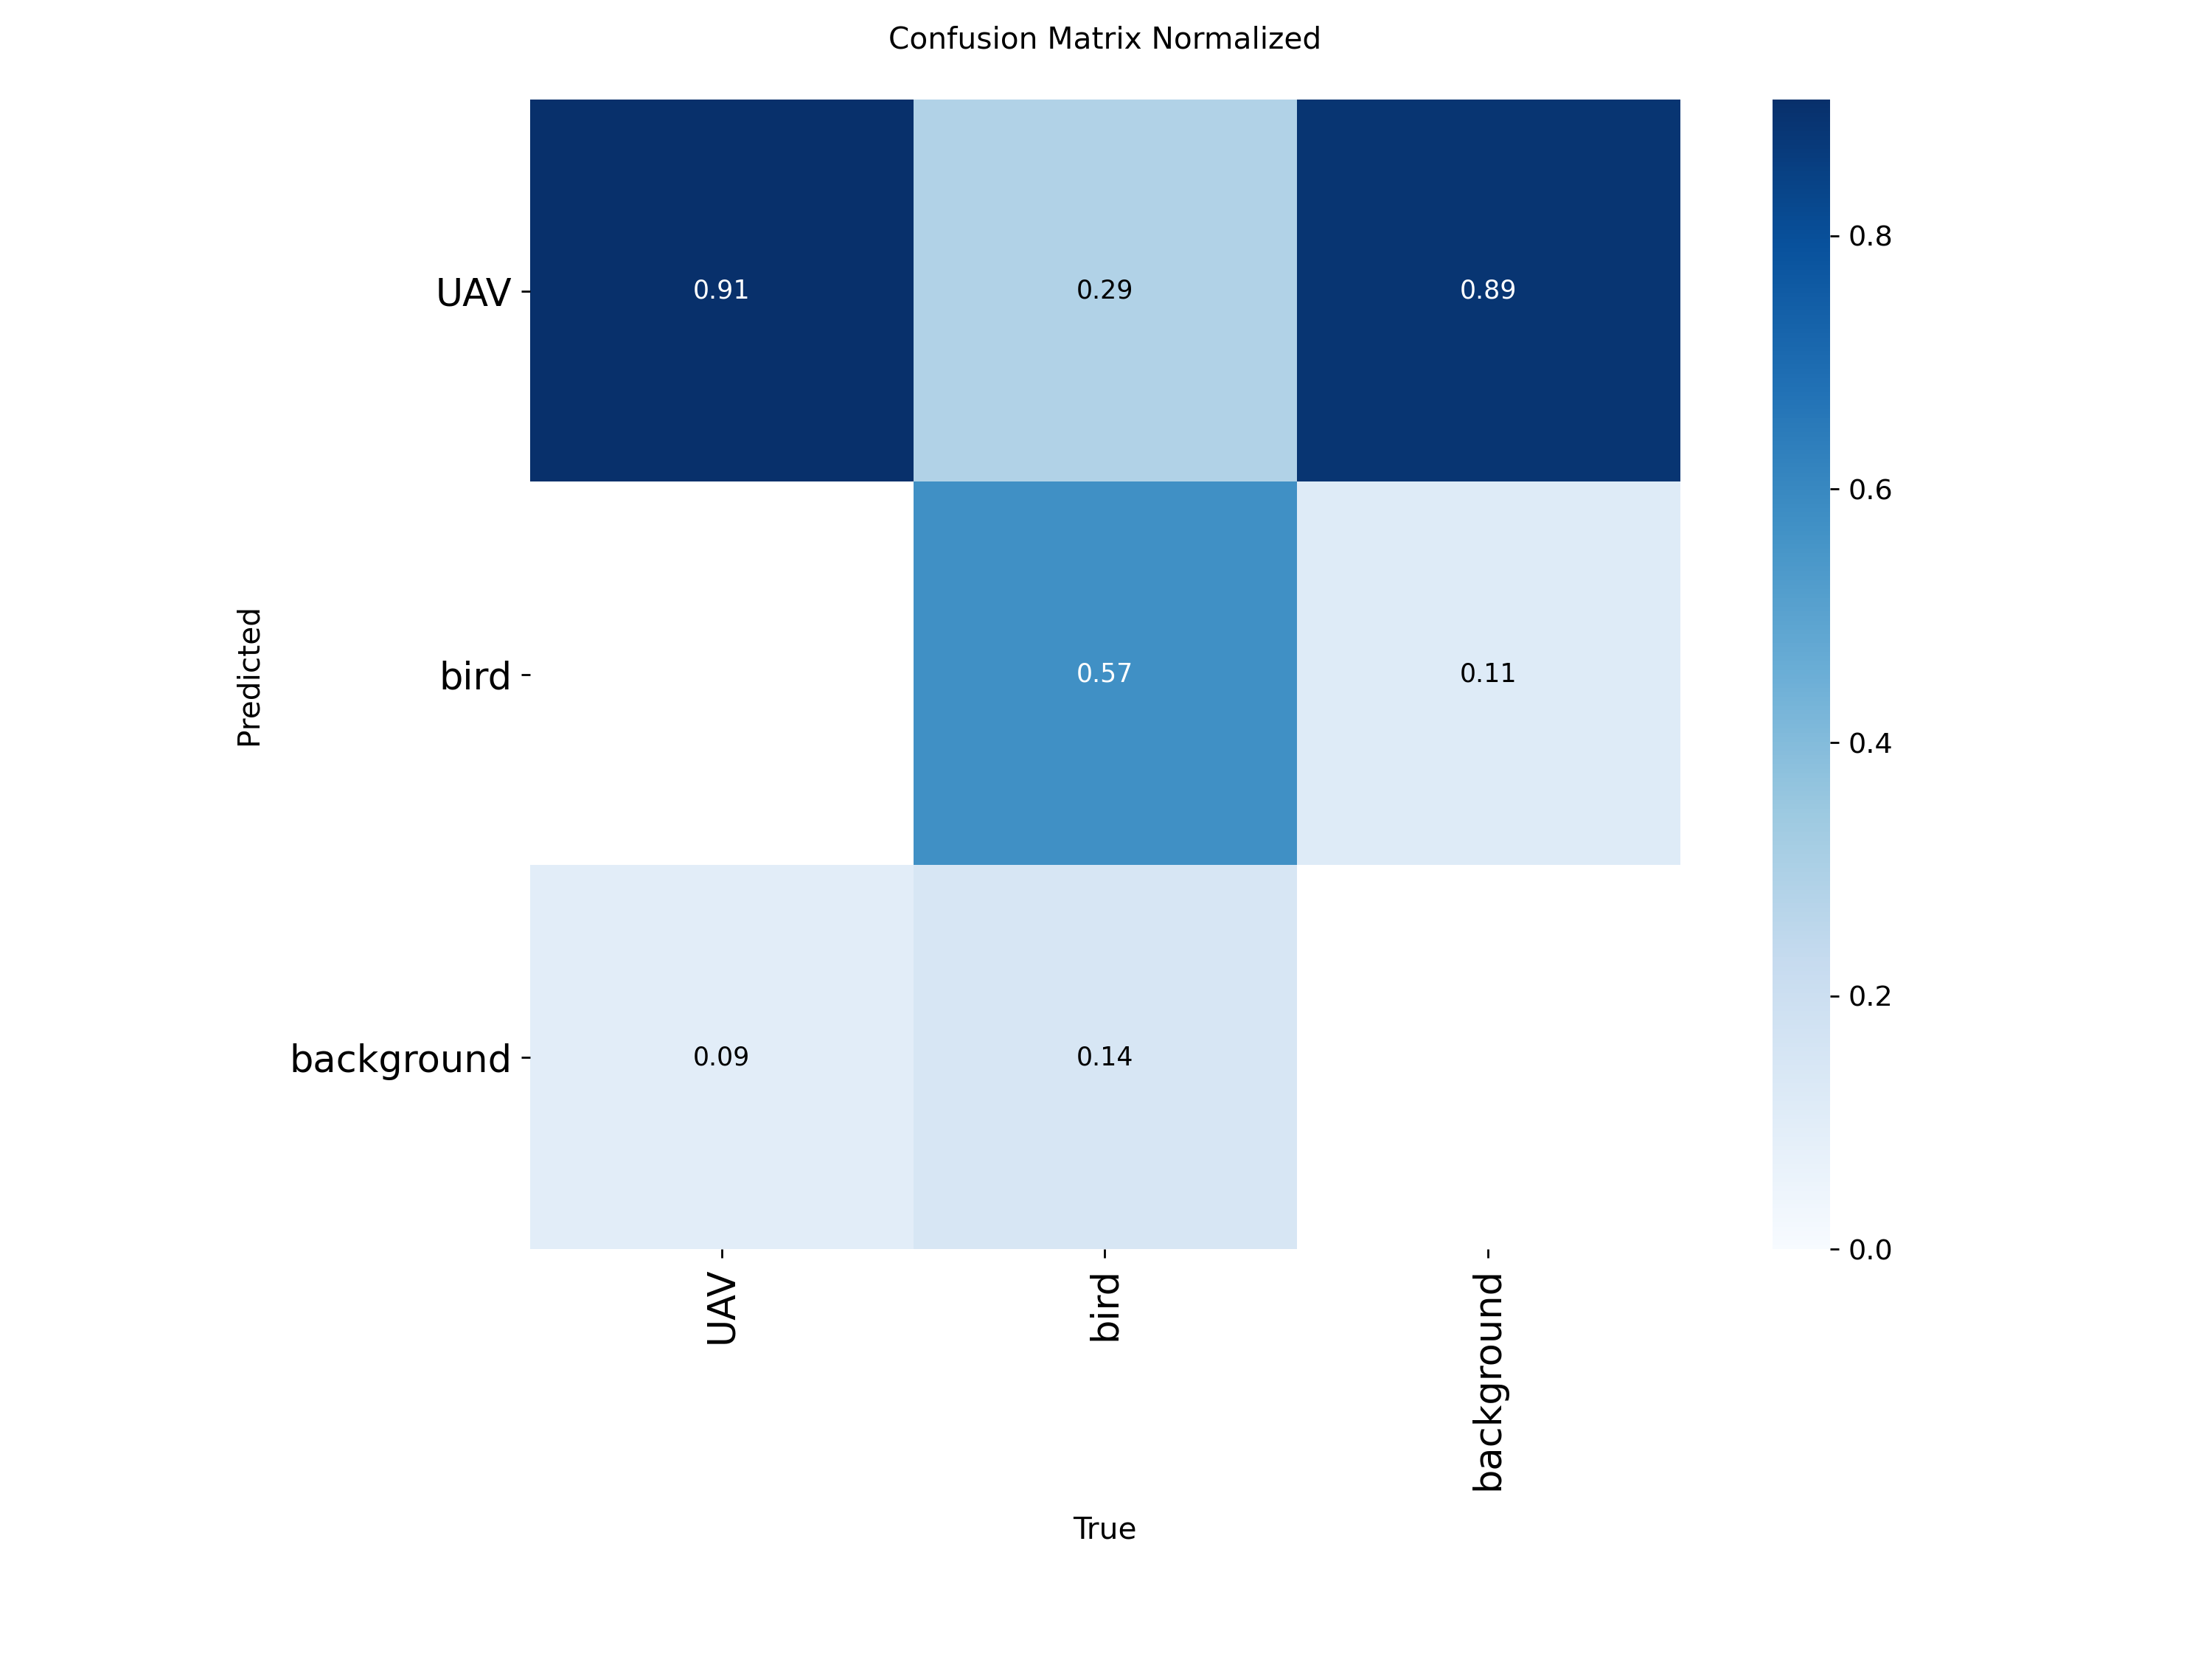


--- BoxPR_curve.png ---


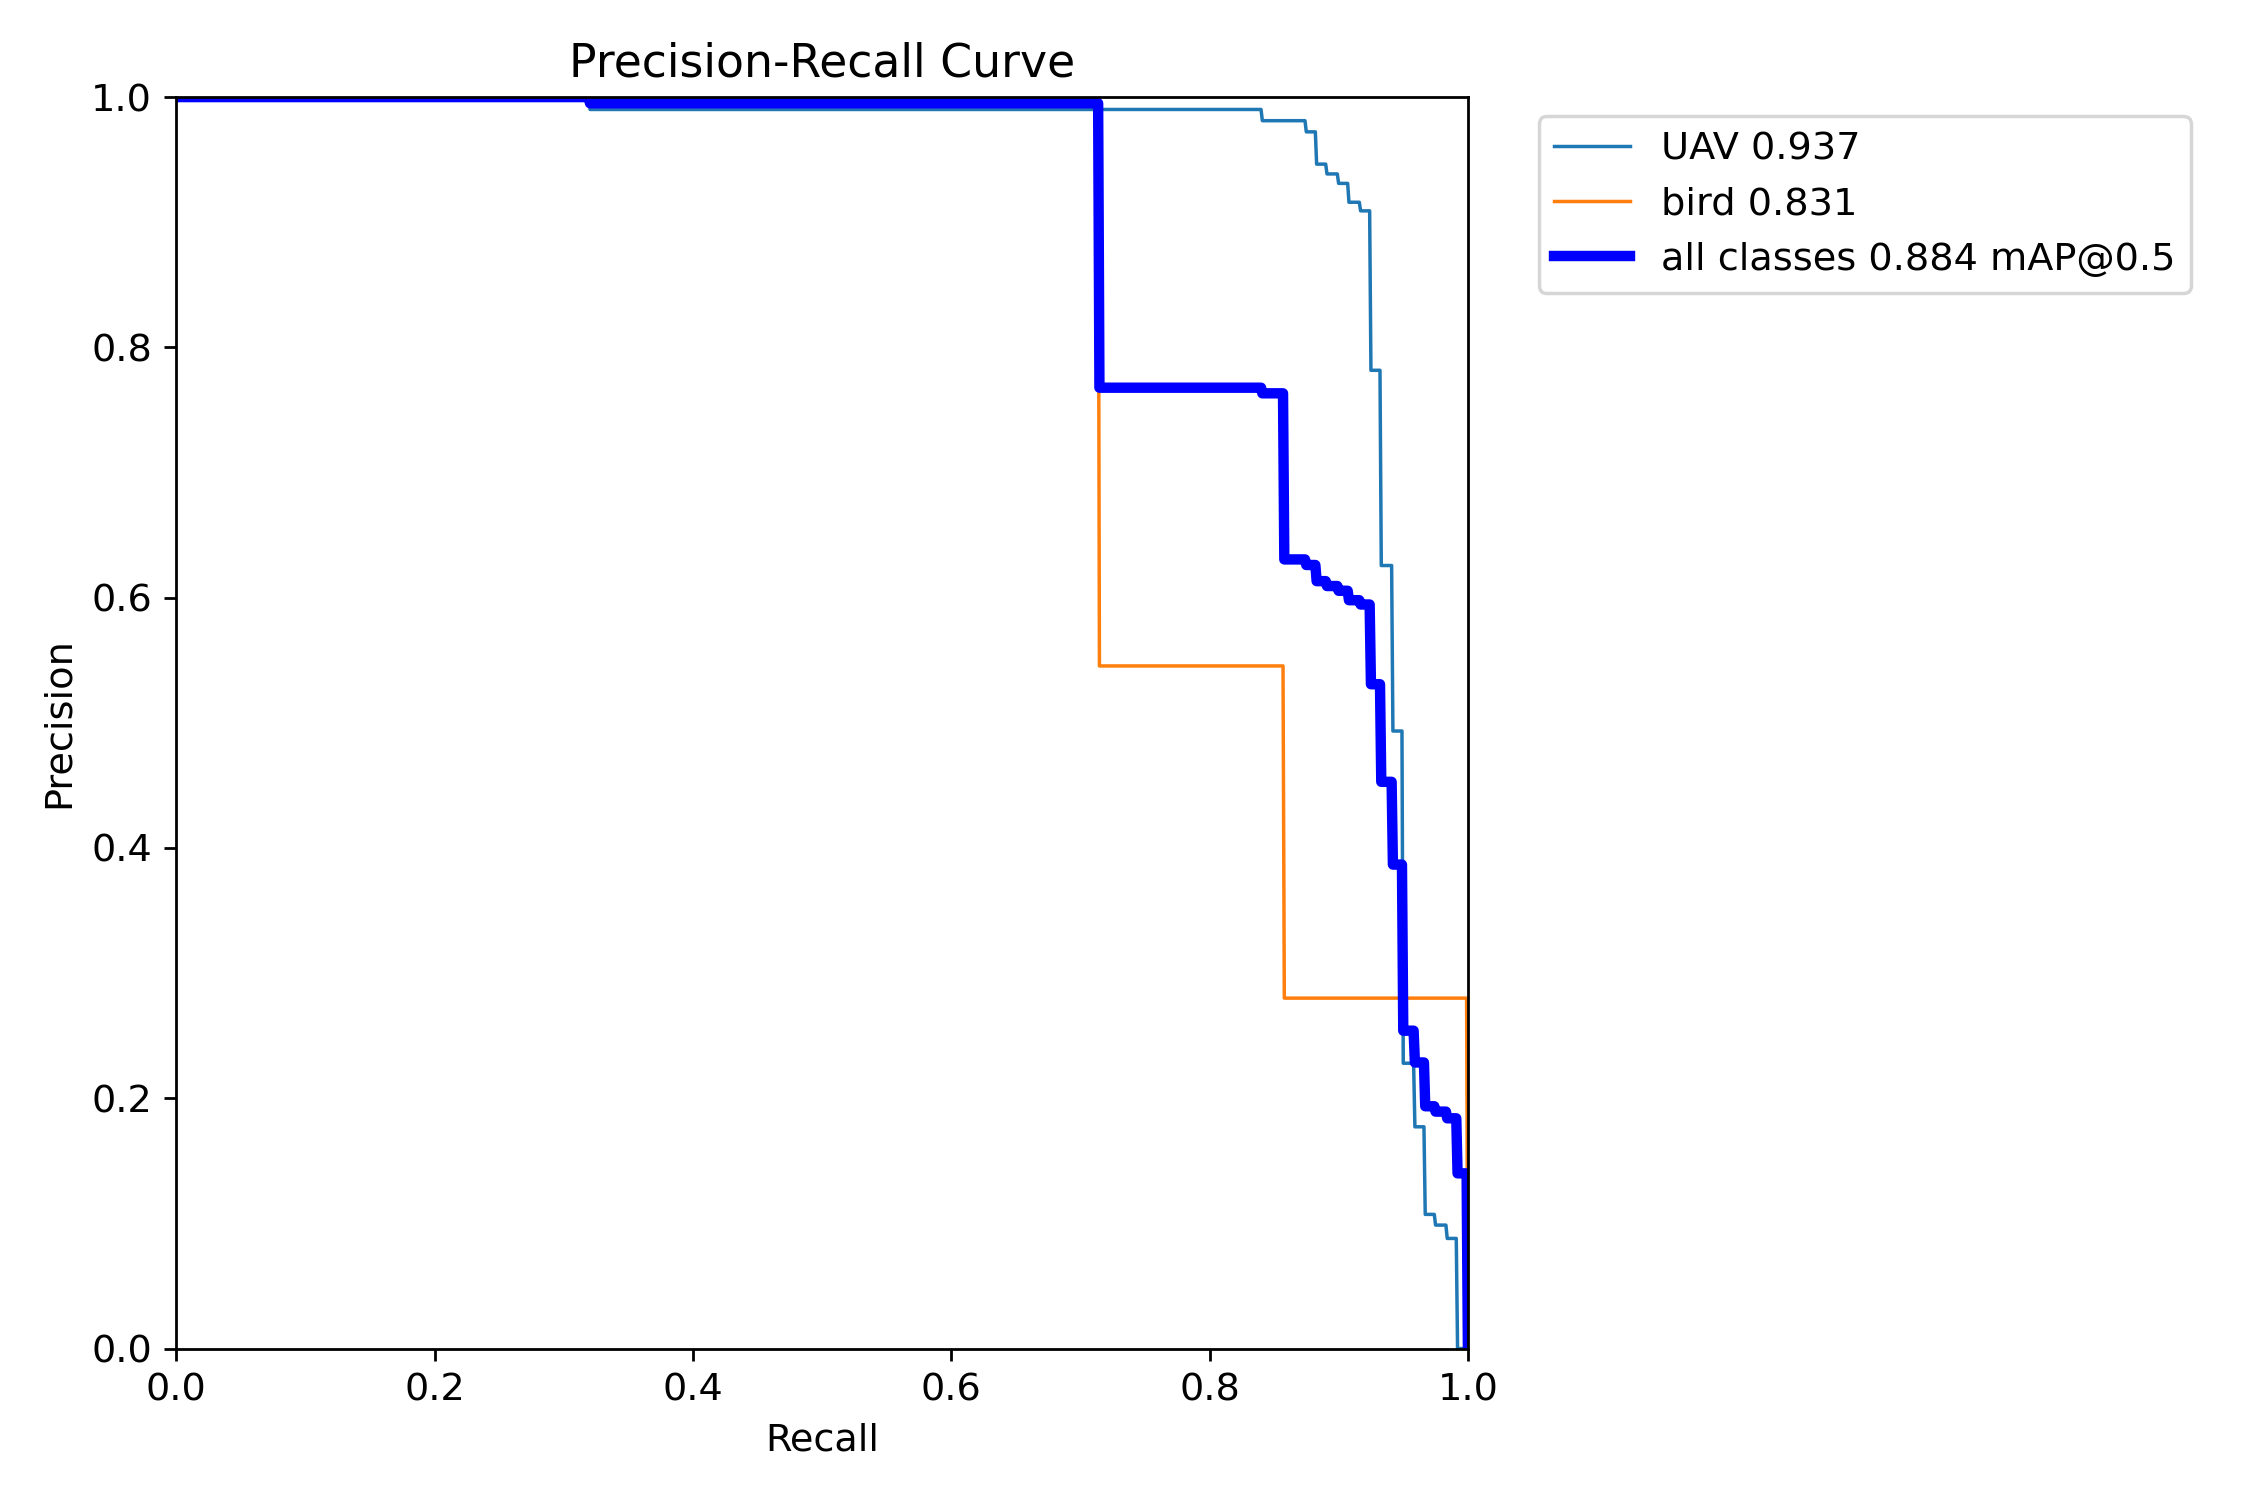


--- BoxF1_curve.png ---


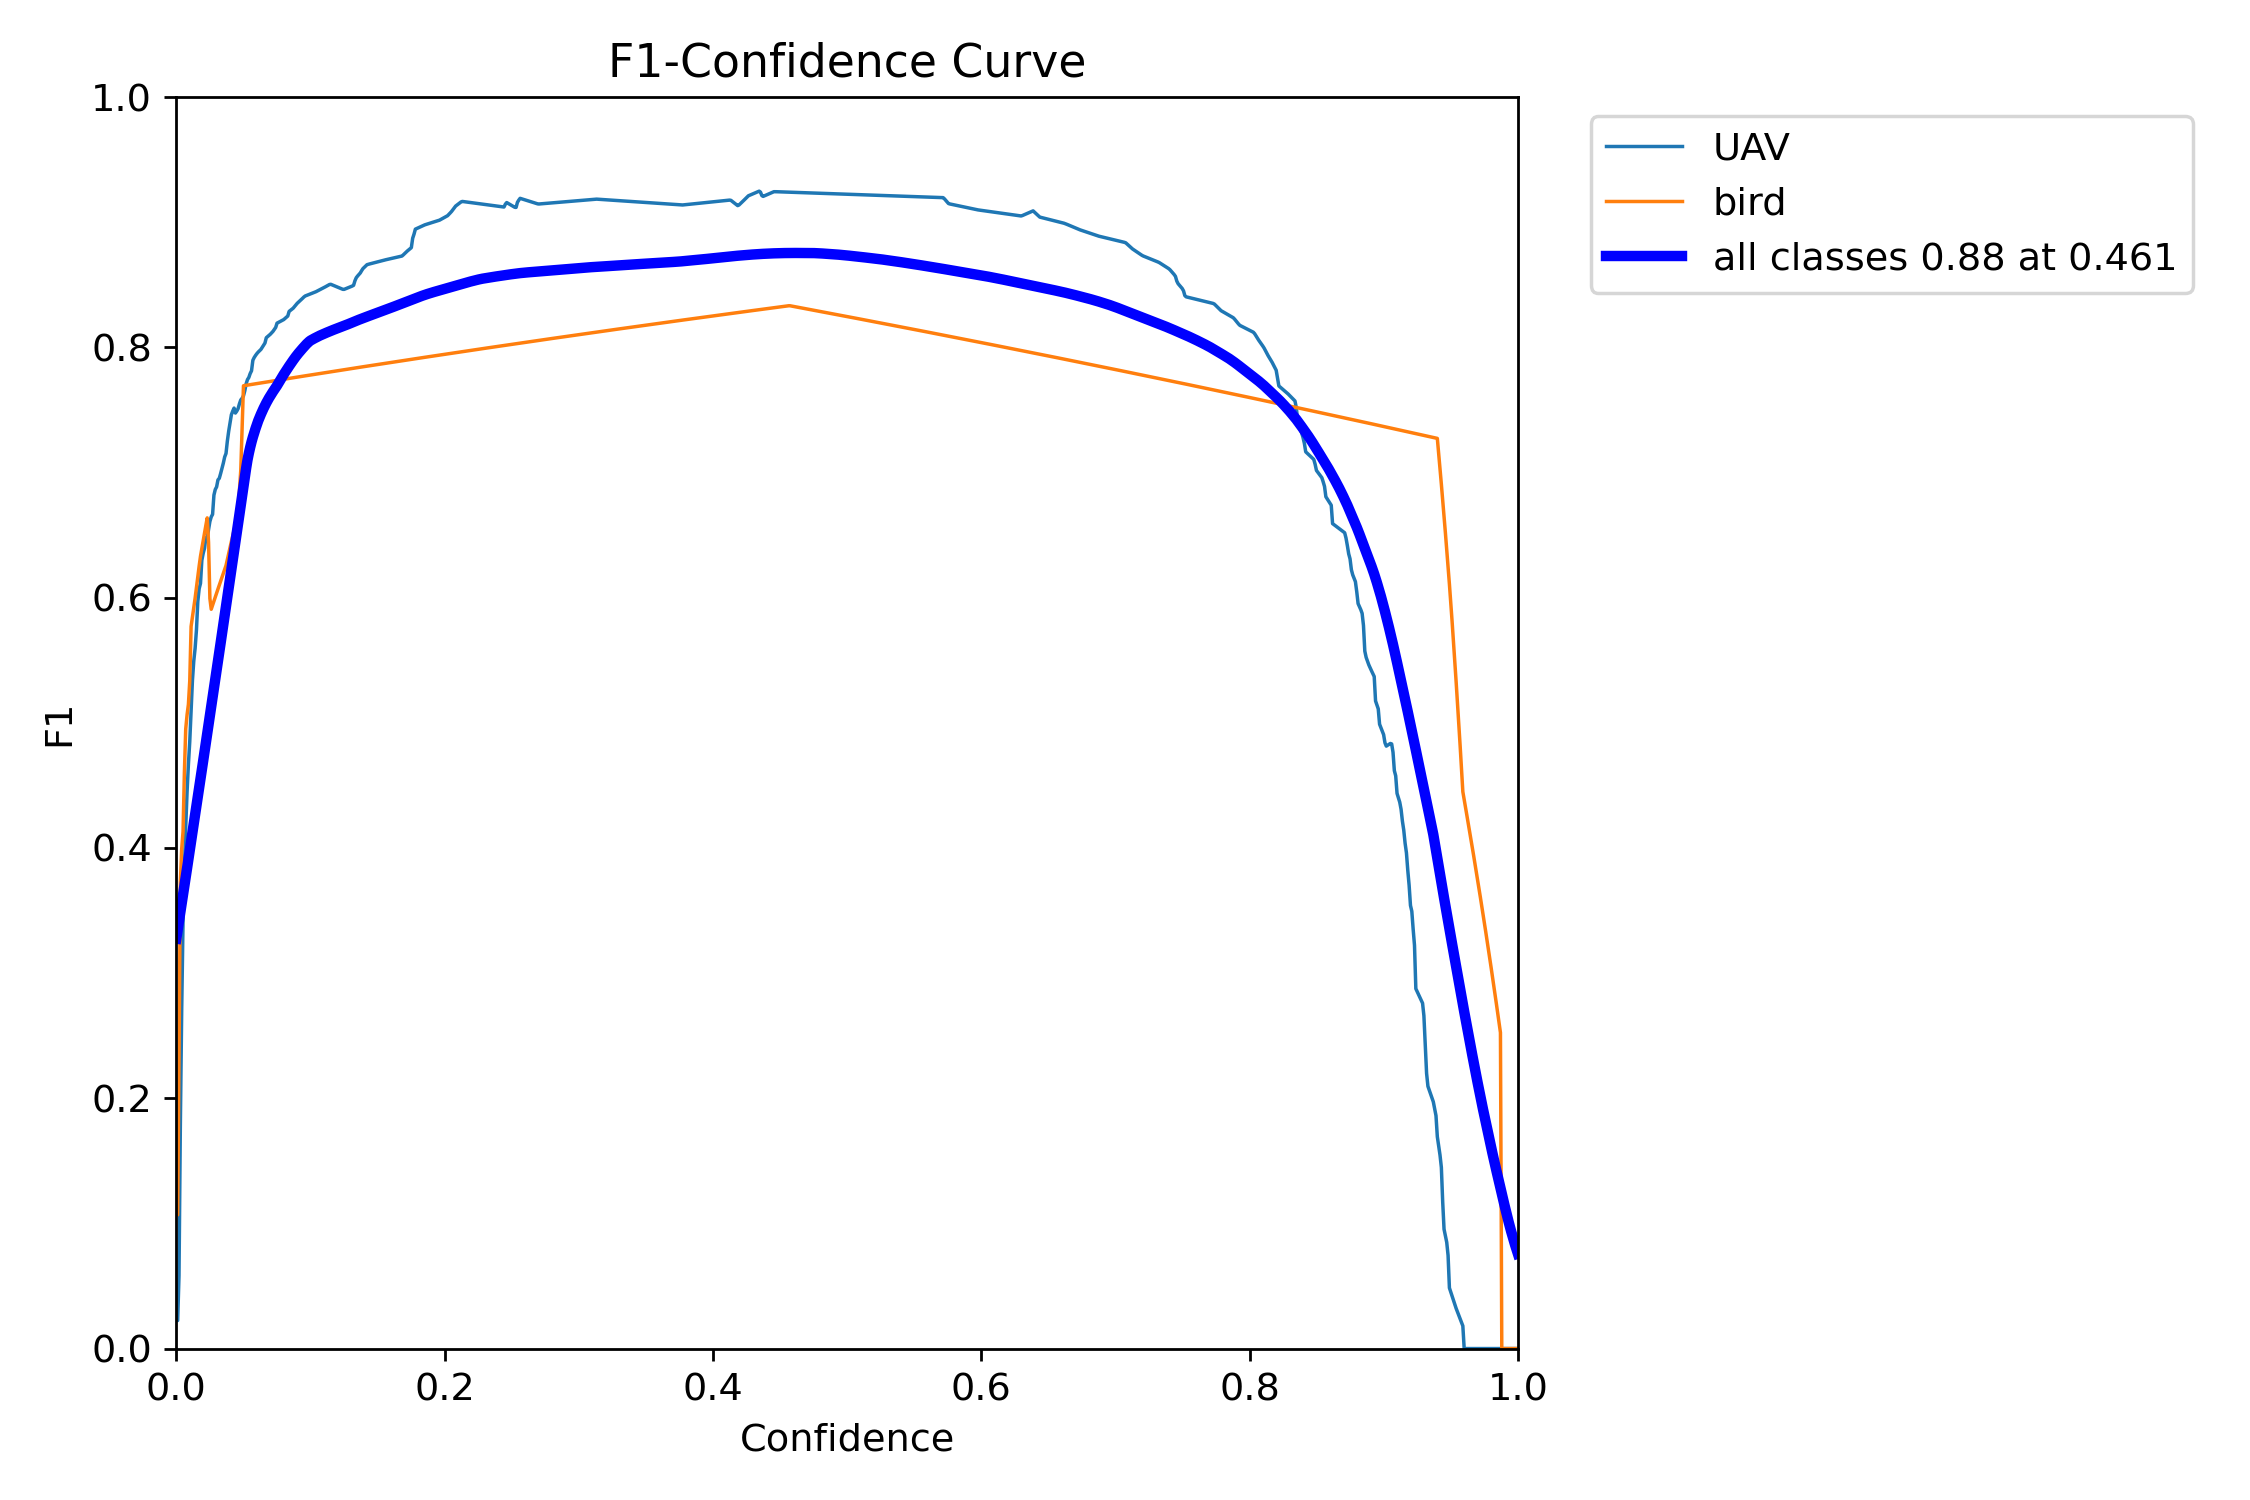

In [14]:
from IPython.display import Image as IPImage
from IPython.display import display

# Візуалізація результатів тренування на незбалансованому датасеті
run_dir_imbalanced = (
    results_imbalanced.save_dir
)  # results_imbalanced — те, що повернув model.train()

for fname in [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
]:
    fpath = os.path.join(run_dir_imbalanced, fname)
    if os.path.exists(fpath):
        print(f"\n--- {fname} ---")
        display(IPImage(fpath, width=700))
    else:
        print(f"Файл не знайдено: {fpath}")


### Типові помилки та що робити

| Проблема | Ознака | Рішення |
|---|---|---|
| Underfitting | низькі train і val mAP | більше епох, більший batch |
| Overfitting | train mAP >> val mAP | більше даних, аугментація |
| Клас не знаходиться | recall ~ 0 для класу | більше прикладів цього класу |
| Багато false positives | precision низька | підвищити conf threshold |

#### Висновок: вплив class imbalance на recall

Результати підтверджують гіпотезу про вплив дисбалансу класів на recall та точність:

| Клас | Частка в датасеті | Recall | Precision | AP@0.5 |
|---|---|---|---|---|
| UAV | 89% | **0.876** | 0.954 | 0.950 |
| bird | 11% | **0.714** | 0.893 | 0.746 |

Recall рідкісного класу (`bird`) виявився на **16 відсоткових пунктів нижчим**, ніж у домінуючого класу (`UAV`) - модель пропускає майже третину реальних пташок (recall 0.71), тоді як дрони пропускає лише в 11% випадків.

Більш показовіше - розрив у AP@0.5 (**0.950 проти 0.746, майже 21 в.п.**), який враховує не лише recall, а й якість ранжування впевненості моделі. Це означає, що модель не просто рідше знаходить `bird`, а й менш впевнена та менш стабільна у своїх передбаченнях для цього класу навіть тоді, коли знаходить його правильно.

**Причина**: модель бачила під час навчання значно менше прикладів `bird` (72 фото проти 588 для UAV), тому градієнти від частого класу домінували в loss, і мережа краще "вивчила" ознаки UAV.

**Застереження щодо статистичної значущості**: валідаційна вибірка містить лише 7 екземплярів класу `bird` (проти 119 для UAV) — при такому малому N кожен окремий пропуск сильно впливає на відсоток recall (одна помилка ~ 14 в.п.). 
Для надійнішого висновку варто було б розмітити більше прикладів `bird` або повторити експеримент на кількох випадкових поділах датасету.

## Завдання 5 - ONNX benchmark
_Порівняйте час інференсу PyTorch `.pt` vs ONNX Runtime._

#### Експорт в ONNX

In [15]:
# Експорт в ONNX
if os.path.exists(best_pt):
    model_export = YOLO(best_pt)
    export_path = model_export.export(format="onnx", simplify=True)
    print(f"ONNX збережено: {export_path}")

    onnx_size = os.path.getsize(export_path) / (1024**2)
    pt_size = os.path.getsize(best_pt) / (1024**2)
    print(f"PT  розмір: {pt_size:.1f} MB")
    print(f"ONNX розмір: {onnx_size:.1f} MB")
else:
    print("best.pt не знайдено — спочатку запустіть тренування.")


Ultralytics 8.4.142  Python-3.14.5 torch-2.13.0+cu132 CPU (AMD Ryzen 5 7500F 6-Core Processor)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 2.2 GFLOPs

PyTorch: starting from 'D:\CV\src\runs\detect\runs\uav_ep50\weights\best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 5, 3549) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success  1.3s, saved as 'D:\CV\src\runs\detect\runs\uav_ep50\weights\best.onnx' (9.2 MB)

Export complete (1.4s)
Results saved to D:\CV\src\runs\detect\runs\uav_ep50\weights\best.onnx
Predict:         yolo predict task=detect model=D:\CV\src\runs\detect\runs\uav_ep50\weights\best.onnx imgsz=416 
Validate:        yolo val task=detect model=D:\CV\src\runs\detect\runs\uav_ep50\weights\best.onnx imgsz=416 data=d:\CV\src\bw_uaw-1\data.yaml  
Visualize:       https://netron.app
ONNX збережено: D:\CV\src\runs\detect\runs\uav_ep50\weights\best.onnx
PT  розмір: 

### Інференс через ONNX Runtime (без PyTorch)
Корисно на edge-пристроях де PyTorch не встановлений

In [16]:
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(
        export_path, providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    )
    print("Input:", sess.get_inputs()[0].name, sess.get_inputs()[0].shape)
    print("Output:", sess.get_outputs()[0].name, sess.get_outputs()[0].shape)
except ImportError:
    print("onnxruntime не встановлено: pip install onnxruntime-gpu")

# Для GPU: providers=["CUDAExecutionProvider", "CPUExecutionProvider"]


Input: images [1, 3, 416, 416]
Output: output0 [1, 5, 3549]


### Бенчмарк: PyTorch `.pt` vs ONNX Runtime — час інференсу
_Порівняйте час інференсу PyTorch `.pt` vs ONNX Runtime._

In [17]:
# Бенчмарк інференсу: PyTorch (.pt) vs ONNX Runtime
# Порівнюємо той самий best.pt і щойно експортований best.onnx на однакових dummy-зображеннях

import time

import numpy as np

N_RUNS = 30
IMG_SIZE = 416  # той самий розмір, з яким тренувалась і експортувалась модель

if os.path.exists(best_pt) and os.path.exists(export_path):
    dummy = np.random.randint(0, 255, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    # --- 1) PyTorch (.pt) ---
    model_pt = YOLO(best_pt)
    # прогрів
    for _ in range(3):
        model_pt.predict(dummy, imgsz=IMG_SIZE, verbose=False)

    t0 = time.time()
    for _ in range(N_RUNS):
        model_pt.predict(dummy, imgsz=IMG_SIZE, verbose=False)
    pt_time_ms = (time.time() - t0) / N_RUNS * 1000

    # --- 2) ONNX Runtime ---
    import onnxruntime as ort

    sess = ort.InferenceSession(
        export_path, providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    )
    input_name = sess.get_inputs()[0].name

    # підготовка тензора вручну: HWC uint8 -> NCHW float32 [0,1]
    def preprocess(img):
        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)[None, ...]  # (1, 3, H, W)
        return np.ascontiguousarray(img)

    dummy_onnx = preprocess(dummy)

    # прогрів
    for _ in range(3):
        sess.run(None, {input_name: dummy_onnx})

    t0 = time.time()
    for _ in range(N_RUNS):
        sess.run(None, {input_name: dummy_onnx})
    onnx_time_ms = (time.time() - t0) / N_RUNS * 1000

    # --- Результат ---
    print(f"Усереднено по {N_RUNS} прогонах, imgsz={IMG_SIZE}:")
    print(f"PyTorch (.pt):    {pt_time_ms:.2f} мс/зображення")
    print(f"ONNX Runtime:     {onnx_time_ms:.2f} мс/зображення")
    speedup = pt_time_ms / onnx_time_ms
    faster = "ONNX Runtime" if speedup > 1 else "PyTorch"
    print(f"\n{faster} швидший у {max(speedup, 1 / speedup):.2f} рази")
else:
    print(
        "best.pt або best.onnx не знайдено — спочатку виконайте тренування та експорт."
    )


Усереднено по 30 прогонах, imgsz=416:
PyTorch (.pt):    8.78 мс/зображення
ONNX Runtime:     5.07 мс/зображення

ONNX Runtime швидший у 1.73 рази


### _**Висновок по завданню**: PyTorch (.pt) vs ONNX Runtime - час інференсу_

| Формат | Пристрій | Розмір файлу | Час інференсу (imgsz=416), мс/зображення |
|---|---|---|---|
| PyTorch (.pt) | GPU (RTX 3060 Ti) | 5.1 MB | 8.78 |
| ONNX Runtime | GPU (RTX 3060 Ti, CUDAExecutionProvider) | 9.2 MB | 5.07 |

**ONNX Runtime виявився швидшим у 1.73 рази**, навіть при порівнянні на одному й тому ж пристрої (GPU vs GPU) та на правильній моделі - fine-tuned 
`best.pt` з 50 епох (Завдання 2).

Цікаво, що при цьому ONNX-файл майже вдвічі важчий за вихідний `.pt` (9.2 MB проти 5.1 MB) — формат ONNX зберігає граф обчислень і ваги менш компактно, ніж рідний формат PyTorch (state_dict), плюс сюди додається метадані графа. Розмір файлу і швидкість інференсу — незалежні характеристики: важчий файл не означає повільнішу модель.

Причина виграшу в швидкості - не в самих GPU-обчисленнях (CUDA-ядра виконують ту саму роботу), а в обв'язці навколо них:

- **PyTorch / Ultralytics `model.predict()`** виконує весь пайплайн через динамічний граф і Python-код: препроцесинг, прохід по шарах з диспетчеризацією на кожному кроці, NMS, збірку результатів у зручні об'єкти (`Results`, `Boxes`). Кожен виклик — накладні витрати інтерпретатора.
- **ONNX Runtime** працює зі статичним, заздалегідь оптимізованим графом (fusion операцій, constant folding - частина цього робить `simplify=True`  при експорті). Рантайм виконує граф без участі Python на кожному кроці.

_**Практичний висновок**: для продакшн-інференсу (особливо на edge-пристроях або в high-throughput сценаріях) ONNX Runtime дає відчутний виграш у швидкості навіть без зміни заліза - лише за рахунок формату виконання графу. Для цільової платформи (Nvidia Jetson, Rockchip RK3588) це особливо релевантно: 
GPU/NPU там зазвичай працює через ONNX або власні SDK, а не через PyTorch напряму, тож перехід у ONNX - не просто оптимізація швидкості, а й практична необхідність для деплою._